# 🧠 1D CNN TFLite Model Evaluator (10% Data Sample)

This Jupyter Notebook evaluates the 1D CNN TFLite models (`cnn_Future_Hypotension.tflite`, `cnn_Future_Hypoxia.tflite`, `cnn_Future_Tachycardia.tflite`) on a **10% sample of the dataset**, generating confusion matrices and benchmark metrics.

### ⚙️ Dataset Sample Configuration:
- `SAMPLE_PCT = 0.10` in Cell 2 evaluates **10% of the dataset**.
- Change `SAMPLE_PCT = 0.10` to `0.20`, `0.50`, or `1.00` (100% full dataset) whenever needed.


In [10]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

try:
    import tflite_runtime.interpreter as tflite
except ImportError:
    import tensorflow.lite as tflite

%matplotlib inline
print("All libraries imported successfully!")


All libraries imported successfully!


In [11]:
# ==============================================================================
# 🛠️ CONFIGURATION PARAMETERS (ADJUST THESE VALUES)
# ==============================================================================

# Fraction of dataset to sample (0.10 = 10% sample)
SAMPLE_PCT = 1

# Sliding window parameters
WINDOW_SIZE = 600   # 10-minute window in seconds (600 samples at 1 Hz)
STRIDE = 10         # Window step size in seconds
DECISION_THRESHOLD = 0.7

# Data directory path
DATA_DIR = "../process_labeled_data"
if not os.path.exists(DATA_DIR):
    DATA_DIR = "process_labeled_data"
if not os.path.exists(DATA_DIR):
    DATA_DIR = "../patient_raw_data"

TARGET_CONDITIONS = ["Future_Hypotension", "Future_Hypoxia", "Future_Tachycardia"]

BASE_FEATURES = [
    "Solar8000/HR", "Solar8000/ART_SBP", "Solar8000/ART_DBP", "Solar8000/ART_MBP",
    "Solar8000/PLETH_SPO2", "Solar8000/RR_CO2", "Solar8000/ETCO2", "Primus/FIO2", "Solar8000/BT"
]
ENGINEERED_FEATURES = [
    "Feature_Pulse_Pressure", "Feature_Shock_Index", "Feature_Modified_Shock_Index",
    "Feature_Rate_Pressure_Product", "Feature_HR_Mean_60s", "Feature_HR_Std_60s",
    "Feature_HR_Delta_60s", "Feature_MBP_Mean_60s", "Feature_MBP_Std_60s", "Feature_MBP_Delta_60s"
]
CHANNELS = BASE_FEATURES + ENGINEERED_FEATURES

print(f"Configured: SAMPLE_PCT={SAMPLE_PCT*100:.1f}% | DATA_DIR={DATA_DIR} | STRIDE={STRIDE}s")


Configured: SAMPLE_PCT=100.0% | DATA_DIR=../process_labeled_data | STRIDE=10s


In [12]:
# Load 1D CNN Scaler & TFLite Interpreters
with open("scaler_1d_cnn.json") as f:
    cnn_sc = json.load(f)
cnn_means = np.array(list(cnn_sc["mean"].values()), dtype=np.float32)
cnn_stds = np.array(list(cnn_sc["std"].values()), dtype=np.float32)

cnn_interpreters = {}
for target in TARGET_CONDITIONS:
    interp = tflite.Interpreter(model_path=f"cnn_{target}.tflite")
    interp.allocate_tensors()
    cnn_interpreters[target] = interp

print("1D CNN TFLite models and scaler loaded successfully!")


1D CNN TFLite models and scaler loaded successfully!


In [13]:
# Discover and Sample 10% of Patient CSV Files
all_csvs = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
total_files = len(all_csvs)
sample_count = max(1, int(total_files * SAMPLE_PCT))

step = max(1, total_files // sample_count)
sampled_csvs = all_csvs[::step][:sample_count]

print(f"Sampling {len(sampled_csvs)} out of {total_files} patient files ({SAMPLE_PCT*100:.1f}% dataset sample)...")

ground_truth = {t: [] for t in TARGET_CONDITIONS}
predicted_probs = {t: [] for t in TARGET_CONDITIONS}

total_windows = 0
for idx, csv_file in enumerate(sampled_csvs, 1):
    try:
        df = pd.read_csv(csv_file)
        if not all(c in df.columns for c in CHANNELS):
            continue
        df_ch = df[CHANNELS].ffill().bfill().fillna(0)
        arr_data = df_ch.values.astype(np.float32)
        N = len(arr_data)
        if N < WINDOW_SIZE:
            continue
            
        for start_idx in range(0, N - WINDOW_SIZE + 1, STRIDE):
            end_idx = start_idx + WINDOW_SIZE
            window_raw = arr_data[start_idx:end_idx]
            window_scaled = ((window_raw - cnn_means) / cnn_stds).reshape(1, WINDOW_SIZE, 19).astype(np.float32)
            
            for target in TARGET_CONDITIONS:
                y_val = df[target].iloc[end_idx - 1] if target in df.columns else 0
                y_true_bin = 1 if y_val > 0.5 else 0
                
                interp = cnn_interpreters[target]
                in_idx = interp.get_input_details()[0]["index"]
                out_idx = interp.get_output_details()[0]["index"]
                interp.set_tensor(in_idx, window_scaled)
                interp.invoke()
                prob = float(interp.get_tensor(out_idx)[0][0])
                
                ground_truth[target].append(y_true_bin)
                predicted_probs[target].append(prob)
                
            total_windows += 1
    except Exception as e:
        continue

print(f"Processing Complete! Evaluated {total_windows} 10-minute windows across {len(sampled_csvs)} files.")


Sampling 3764 out of 3764 patient files (100.0% dataset sample)...
Processing Complete! Evaluated 4686674 10-minute windows across 3764 files.


 1D CNN PERFORMANCE METRICS: Future Hypotension
  Accuracy    : 0.3171 (31.71%)
  Precision   : 0.2918
  Recall      : 1.0000
  Specificity : 0.0497
  F1-Score    : 0.4517
  ROC-AUC     : 0.7529
  Confusion Matrix -> TP: 1318657 | FP: 3200737 | TN: 167280 | FN: 0
 1D CNN PERFORMANCE METRICS: Future Hypoxia
  Accuracy    : 0.0493 (4.93%)
  Precision   : 0.0493
  Recall      : 1.0000
  Specificity : 0.0000
  F1-Score    : 0.0939
  ROC-AUC     : 0.5000
  Confusion Matrix -> TP: 230973 | FP: 4455701 | TN: 0 | FN: 0
 1D CNN PERFORMANCE METRICS: Future Tachycardia
  Accuracy    : 0.1528 (15.28%)
  Precision   : 0.0994
  Recall      : 0.9383
  Specificity : 0.0665
  F1-Score    : 0.1798
  ROC-AUC     : 0.7031
  Confusion Matrix -> TP: 435274 | FP: 3942080 | TN: 280696 | FN: 28624


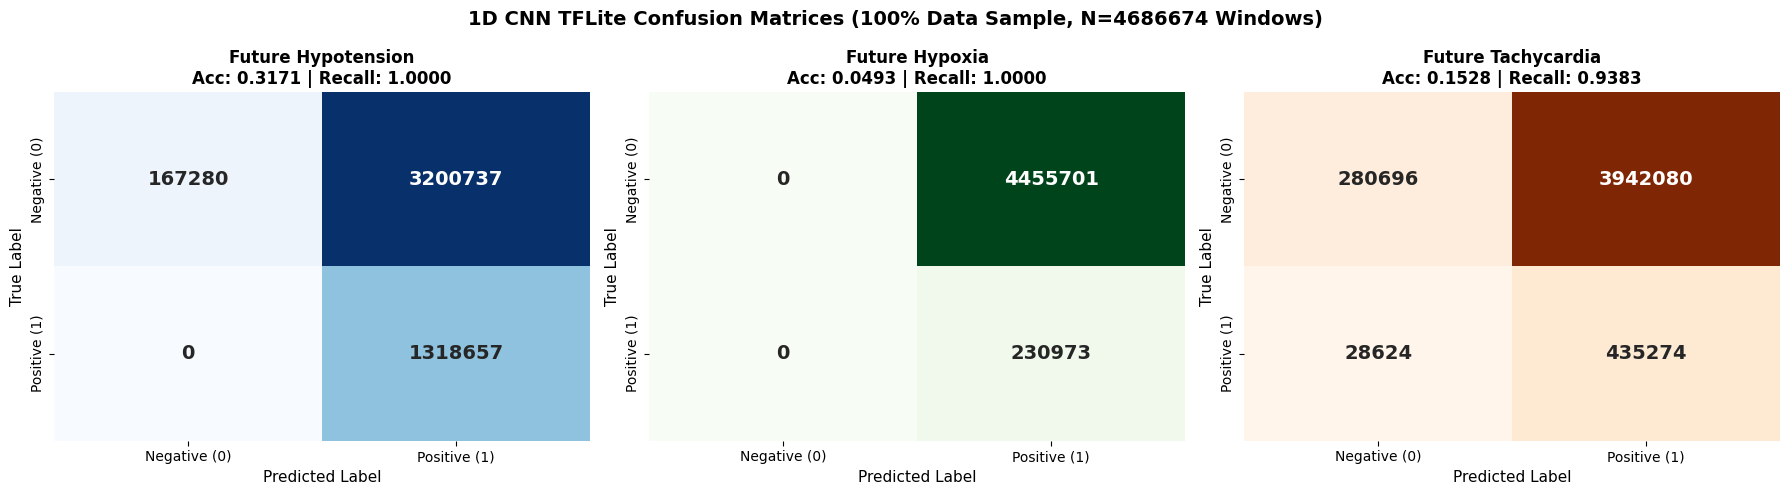

In [14]:
# Render Confusion Matrices & Performance Metrics Inline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"1D CNN TFLite Confusion Matrices ({SAMPLE_PCT*100:.0f}% Data Sample, N={total_windows} Windows)", fontsize=14, fontweight="bold")
cm_colors = ["Blues", "Greens", "Oranges"]

for i, target in enumerate(TARGET_CONDITIONS):
    y_true = np.array(ground_truth[target])
    p_arr = np.array(predicted_probs[target])
    y_pred = (p_arr >= DECISION_THRESHOLD).astype(int)
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, p_arr) if len(np.unique(y_true)) > 1 else 0.5
    except Exception:
        auc = 0.5
        
    target_title = target.replace("_", " ")
    print("=" * 75)
    print(f" 1D CNN PERFORMANCE METRICS: {target_title}")
    print("=" * 75)
    print(f"  Accuracy    : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision   : {prec:.4f}")
    print(f"  Recall      : {rec:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  F1-Score    : {f1:.4f}")
    print(f"  ROC-AUC     : {auc:.4f}")
    print(f"  Confusion Matrix -> TP: {tp} | FP: {fp} | TN: {tn} | FN: {fn}")
    
    sns.heatmap(cm, annot=True, fmt="d", cmap=cm_colors[i], ax=axes[i], cbar=False,
                annot_kws={"size": 14, "weight": "bold"},
                xticklabels=["Negative (0)", "Positive (1)"],
                yticklabels=["Negative (0)", "Positive (1)"])
    axes[i].set_title(f"{target_title}\nAcc: {acc:.4f} | Recall: {rec:.4f}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Predicted Label", fontsize=11)
    axes[i].set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.show()
